In [1]:
import os
import io
import gc
import math
import time
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms.functional as TF

In [2]:
ROOT = Path(".")
DATASET_DIR = ROOT / "dataset"
TRAIN_DIR = DATASET_DIR / "train_images"
TEST_DIR = DATASET_DIR / "test_images"
TRAIN_CSV = DATASET_DIR / "train_solution.csv"

IMG_SIZE_ANALYSIS = 256
RANDOM_STATE = 42
FAKE_LABEL = 1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(RANDOM_STATE)
print("DEVICE:", DEVICE)

DEVICE: cuda


In [3]:
train_df_raw = pd.read_csv(TRAIN_CSV)
display(train_df_raw.head())
print(train_df_raw.columns.tolist())

def detect_image_col(df: pd.DataFrame):
    preferred = ["image", "image_id", "id", "filename", "file_name", "img", "path", "file"]
    for col in preferred:
        if col in df.columns:
            return col
    obj_cols = [c for c in df.columns if df[c].dtype == "object"]
    if obj_cols:
        return obj_cols[0]
    return df.columns[0]

def detect_label_col(df: pd.DataFrame, image_col: str):
    preferred = ["label", "target", "class", "y"]
    for col in preferred:
        if col in df.columns and col != image_col:
            return col
    for col in df.columns:
        if col == image_col:
            continue
        vals = pd.Series(df[col]).dropna().unique()
        if len(vals) <= 4 and set(vals).issubset({0, 1, "0", "1"}):
            return col
    for col in df.columns:
        if col != image_col:
            return col
    raise ValueError("Не удалось определить колонку с меткой")

IMAGE_COL = detect_image_col(train_df_raw)
LABEL_COL = detect_label_col(train_df_raw, IMAGE_COL)

train_df = train_df_raw[[IMAGE_COL, LABEL_COL]].copy()
train_df.columns = ["image_id", "label"]
train_df["label"] = train_df["label"].astype(int)

print("IMAGE_COL:", IMAGE_COL)
print("LABEL_COL:", LABEL_COL)
display(train_df.head())
print(train_df["label"].value_counts())

,0,0.1
0,1,1
1,2,1
2,3,0
3,4,0
4,5,0


['0', '0.1']
IMAGE_COL: 0
LABEL_COL: 0.1


,image_id,label
0,1,1
1,2,1
2,3,0
3,4,0
4,5,0


label
0    41499
1     8500
Name: count, dtype: int64


In [4]:
def resolve_image_path(image_id, folder: Path):
    s = str(image_id)
    p = Path(s)
    candidates = []

    if p.is_absolute():
        candidates.append(p)
    else:
        candidates.extend([
            folder / s,
            folder / p.name,
        ])
        if p.suffix == "":
            for ext in [".png", ".jpg", ".jpeg", ".webp", ".bmp"]:
                candidates.append(folder / f"{s}{ext}")
                candidates.append(folder / f"{p.name}{ext}")

    for c in candidates:
        if c.exists():
            return c

    return candidates[0]

train_df["image_path"] = train_df["image_id"].apply(lambda x: resolve_image_path(x, TRAIN_DIR))
print("found:", train_df["image_path"].apply(lambda p: Path(p).exists()).sum(), "/", len(train_df))
display(train_df.head())

found: 49999 / 49999


,image_id,label,image_path
0,1,1,dataset\train_images\1.jpg
1,2,1,dataset\train_images\2.jpg
2,3,0,dataset\train_images\3.jpg
3,4,0,dataset\train_images\4.jpg
4,5,0,dataset\train_images\5.jpg


In [5]:
SOBEL_X = torch.tensor(
    [[1, 0, -1],
     [2, 0, -2],
     [1, 0, -1]], dtype=torch.float32
).view(1, 1, 3, 3)

SOBEL_Y = torch.tensor(
    [[1, 2, 1],
     [0, 0, 0],
     [-1, -2, -1]], dtype=torch.float32
).view(1, 1, 3, 3)

HP_LAPL = torch.tensor(
    [[0, -1, 0],
     [-1, 4, -1],
     [0, -1, 0]], dtype=torch.float32
).view(1, 1, 3, 3)

HP_X = torch.tensor(
    [[0, 0, 0],
     [-1, 2, -1],
     [0, 0, 0]], dtype=torch.float32
).view(1, 1, 3, 3)

HP_Y = torch.tensor(
    [[0, -1, 0],
     [0,  2, 0],
     [0, -1, 0]], dtype=torch.float32
).view(1, 1, 3, 3)

def conv_single_channel(ch: torch.Tensor, kernel: torch.Tensor):
    x = ch.unsqueeze(0)  # [1,1,H,W]
    out = F.conv2d(x, kernel, padding=1)
    return out.squeeze(0)

def minmax_unit(x: torch.Tensor, eps: float = 1e-6):
    return (x - x.min()) / (x.max() - x.min() + eps)

def extract_analysis_features_from_pil(img: Image.Image, img_size=256):
    img = img.resize((img_size, img_size), Image.BILINEAR)

    rgb01 = TF.to_tensor(img)  # [3,H,W] in [0,1]
    r, g, b = rgb01[0], rgb01[1], rgb01[2]

    ycbcr01 = TF.to_tensor(img.convert("YCbCr"))
    y = ycbcr01[0:1]
    cb = ycbcr01[1:2]
    cr = ycbcr01[2:3]

    res1 = conv_single_channel(y, HP_LAPL)
    res2 = conv_single_channel(y, HP_X)
    res3 = conv_single_channel(y, HP_Y)

    # FFT по Y
    fft = torch.fft.fft2(y.squeeze(0))
    fft = torch.fft.fftshift(fft)
    fft_mag = torch.abs(fft)

    feats = {
        # mean RGB
        "mean_r": float(r.mean()),
        "mean_g": float(g.mean()),
        "mean_b": float(b.mean()),

        # var RGB
        "var_r": float(r.var(unbiased=False)),
        "var_g": float(g.var(unbiased=False)),
        "var_b": float(b.var(unbiased=False)),

        # mean YCbCr
        "mean_y": float(y.mean()),
        "mean_cb": float(cb.mean()),
        "mean_cr": float(cr.mean()),

        # var YCbCr
        "var_y": float(y.var(unbiased=False)),
        "var_cb": float(cb.var(unbiased=False)),
        "var_cr": float(cr.var(unbiased=False)),

        # residual energies
        "res_energy_1": float((res1 ** 2).mean()),
        "res_energy_2": float((res2 ** 2).mean()),
        "res_energy_3": float((res3 ** 2).mean()),
        "res_energy_total": float(((res1 ** 2).mean() + (res2 ** 2).mean() + (res3 ** 2).mean()) / 3.0),

        # fft energies
        "fft_energy_mean": float((fft_mag ** 2).mean()),
        "fft_energy_logmean": float(torch.log1p(fft_mag).mean()),
        "fft_energy_std": float(torch.log1p(fft_mag).std(unbiased=False)),
    }

    return feats

In [10]:
train_df.columns

Index(['image_id', 'label', 'image_path'], dtype='str')

In [11]:
ANALYSIS_SAMPLE_SIZE = 1000  # можешь поставить None для всего train

real_df = train_df[train_df["label"] == 0]
fake_df = train_df[train_df["label"] == 1]

n_each = ANALYSIS_SAMPLE_SIZE // 2

analysis_df = pd.concat([
    real_df.sample(min(len(real_df), n_each), random_state=RANDOM_STATE),
    fake_df.sample(min(len(fake_df), n_each), random_state=RANDOM_STATE),
], ignore_index=True)

analysis_df = analysis_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(analysis_df.info())
print("analysis_df shape:", analysis_df.shape)
print(analysis_df["label"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_id    1000 non-null   int64 
 1   label       1000 non-null   int64 
 2   image_path  1000 non-null   object
dtypes: int64(2), object(1)
memory usage: 23.6+ KB
None
analysis_df shape: (1000, 3)
label
1    500
0    500
Name: count, dtype: int64


In [12]:
rows = []

for i, row in analysis_df.iterrows():
    img = Image.open(row["image_path"]).convert("RGB")
    feats = extract_analysis_features_from_pil(img, img_size=IMG_SIZE_ANALYSIS)
    feats["label"] = int(row["label"])
    feats["image_id"] = row["image_id"]
    rows.append(feats)

    if (i + 1) % 200 == 0:
        print(f"{i+1}/{len(analysis_df)}")

analysis_feats_df = pd.DataFrame(rows)
display(analysis_feats_df.head())
print(analysis_feats_df.shape)

200/1000
400/1000
600/1000
800/1000
1000/1000


,mean_r,mean_g,mean_b,var_r,var_g,var_b,mean_y,mean_cb,mean_cr,var_y,...,var_cr,res_energy_1,res_energy_2,res_energy_3,res_energy_total,fft_energy_mean,fft_energy_logmean,fft_energy_std,label,image_id
0,0.523271,0.443204,0.397319,0.048249,0.054365,0.057050,0.459998,0.463803,0.544028,0.051028,...,0.000881,0.036634,0.013692,0.011629,0.020652,17211.406250,2.401135,0.768573,1,1442
1,0.415008,0.421165,0.438841,0.051511,0.049265,0.057873,0.419392,0.510428,0.495751,0.049153,...,0.001797,0.032284,0.010413,0.011295,0.017998,14748.399414,2.456973,0.827713,1,2201
2,0.530384,0.451669,0.420286,0.084265,0.069864,0.062453,0.469721,0.471440,0.542105,0.071845,...,0.001587,0.179198,0.055126,0.055471,0.096598,19168.144531,3.062422,0.673941,1,4642
3,0.656614,0.419747,0.443796,0.081952,0.096052,0.091100,0.491397,0.472389,0.616777,0.082931,...,0.008182,0.238481,0.072925,0.072243,0.127883,21259.980469,3.212286,0.691427,1,16028
4,0.763131,0.662380,0.626310,0.063231,0.092174,0.106404,0.687106,0.465916,0.554124,0.082635,...,0.003166,0.325416,0.101751,0.098029,0.175065,36356.046875,3.297739,0.648878,0,27386


(1000, 21)


In [16]:
feature_cols = [c for c in analysis_feats_df.columns if c not in ["label", "image_id"]]

class_means = analysis_feats_df.groupby("label")[feature_cols].mean().T
class_stds = analysis_feats_df.groupby("label")[feature_cols].std().T

In [17]:
real_label = 0 if FAKE_LABEL == 1 else 1
fake_label = FAKE_LABEL

summary_rows = []

for col in feature_cols:
    real_mean = analysis_feats_df.loc[analysis_feats_df["label"] == real_label, col].mean()
    fake_mean = analysis_feats_df.loc[analysis_feats_df["label"] == fake_label, col].mean()

    diff = fake_mean - real_mean
    rel_diff = diff / (abs(real_mean) + 1e-9)

    summary_rows.append({
        "feature": col,
        "real_mean": real_mean,
        "fake_mean": fake_mean,
        "abs_diff": diff,
        "rel_diff_pct": 100 * rel_diff,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("rel_diff_pct", key=lambda s: s.abs(), ascending=False)

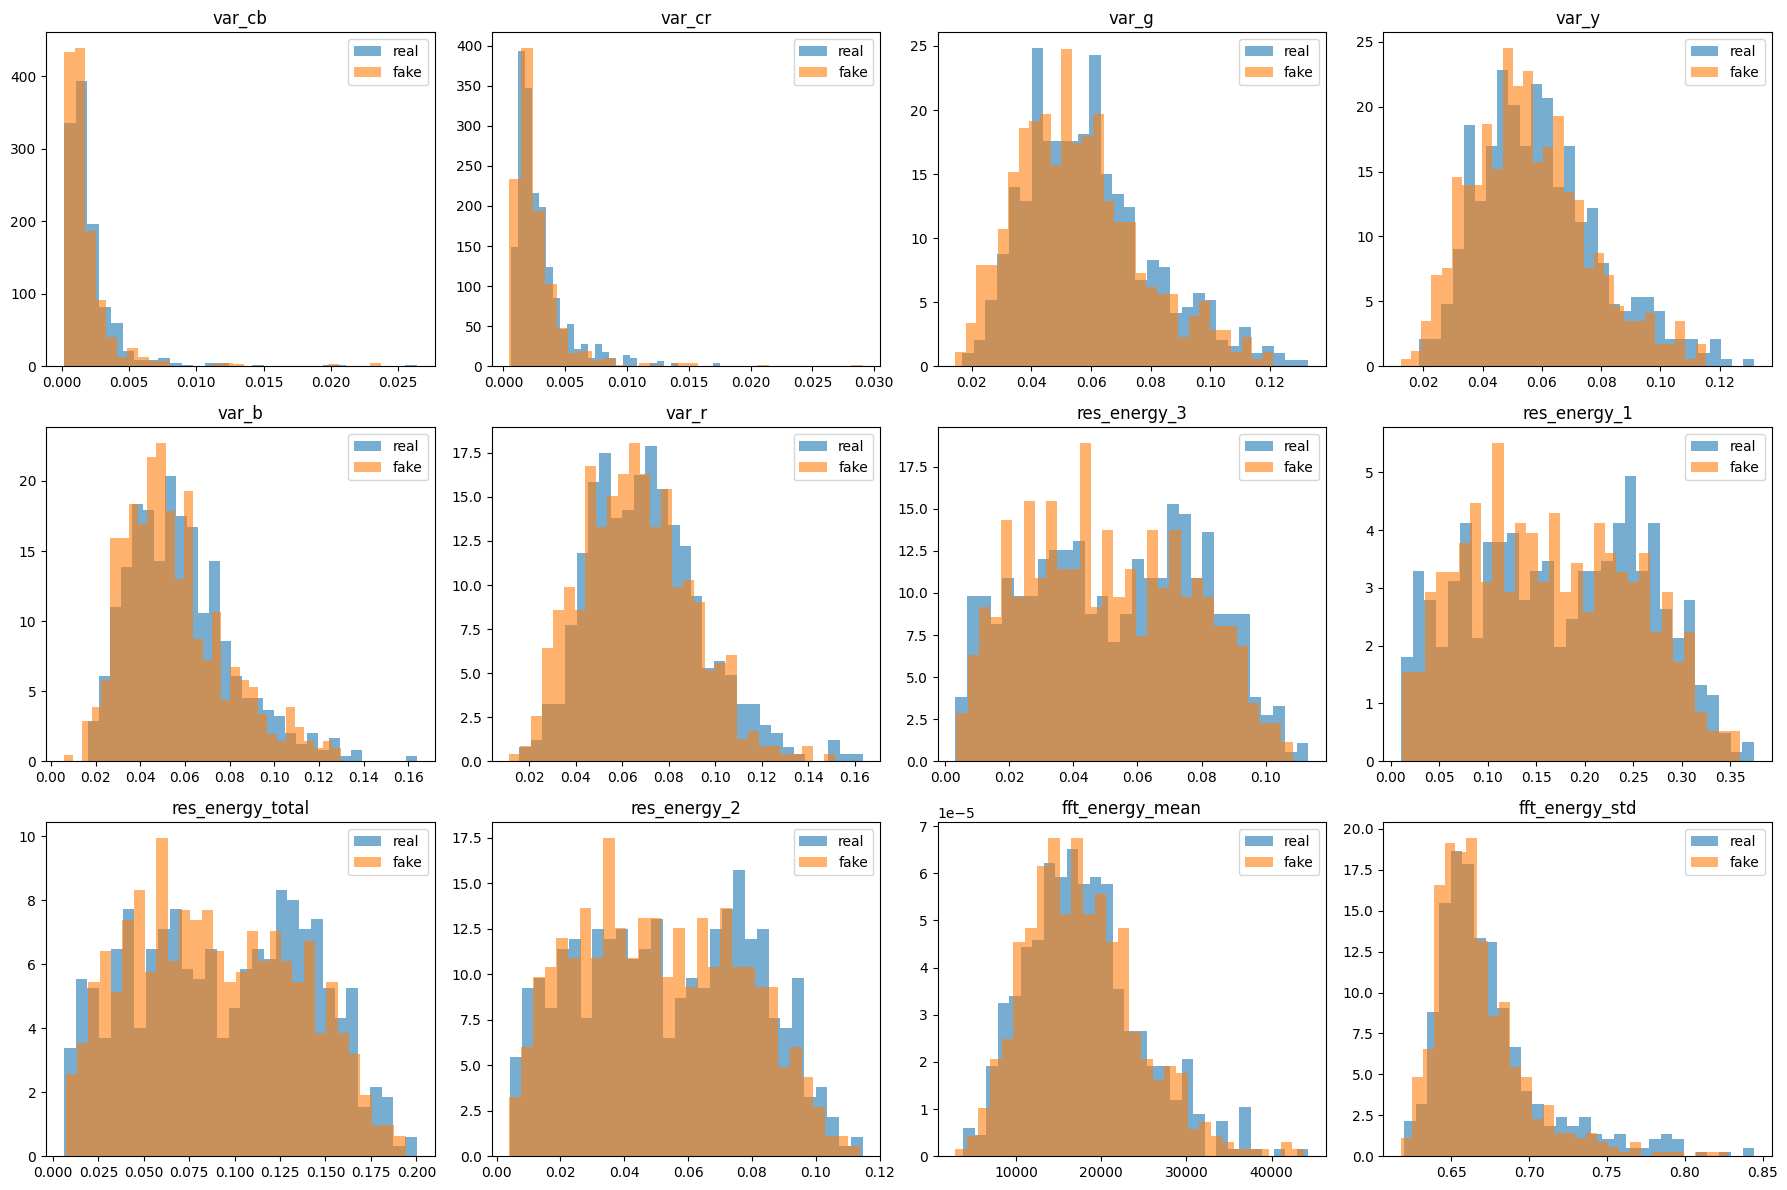

In [15]:
top_features = summary_df["feature"].head(12).tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.ravel()

for ax, feat in zip(axes, top_features):
    x_real = analysis_feats_df.loc[analysis_feats_df["label"] == real_label, feat].values
    x_fake = analysis_feats_df.loc[analysis_feats_df["label"] == fake_label, feat].values

    ax.hist(x_real, bins=30, alpha=0.6, label="real", density=True)
    ax.hist(x_fake, bins=30, alpha=0.6, label="fake", density=True)
    ax.set_title(feat)
    ax.legend()

for ax in axes[len(top_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [18]:
train_part, val_part = train_test_split(
    train_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_df["label"]
)

train_part = train_part.reset_index(drop=True)
val_part = val_part.reset_index(drop=True)

print(train_part.shape, val_part.shape)
print(train_part["label"].value_counts(normalize=True))
print(val_part["label"].value_counts(normalize=True))

(39999, 3) (10000, 3)
label
0    0.829996
1    0.170004
Name: proportion, dtype: float64
label
0    0.83
1    0.17
Name: proportion, dtype: float64


In [38]:
TRAIN_SAMPLE = 1000   # для быстрого запуска
VAL_SAMPLE = 200
train_part_small = (
    train_part.groupby("label")
    .apply(lambda x: x.sample(min(len(x), TRAIN_SAMPLE // 2), random_state=RANDOM_STATE)).reset_index()
)

val_part_small = (
    val_part.groupby("label")
    .apply(lambda x: x.sample(min(len(x), VAL_SAMPLE // 2), random_state=RANDOM_STATE)).reset_index()
)
print("train_part_small:", train_part_small.shape)
print("val_part_small:", val_part_small.shape)
print(train_part_small["label"].value_counts())
print(val_part_small["label"].value_counts())

train_part_small: (1000, 5)
val_part_small: (200, 5)
label
0    500
1    500
Name: count, dtype: int64
label
0    100
1    100
Name: count, dtype: int64


In [40]:
FLAT_IMG_SIZE = 128

def extract_streams_for_flat_model(img: Image.Image, img_size=128):
    img = img.resize((img_size, img_size), Image.BILINEAR)

    # RGB
    rgb01 = TF.to_tensor(img)
    rgb = (rgb01 - 0.5) / 0.5

    # Color branch
    ycbcr01 = TF.to_tensor(img.convert("YCbCr"))
    y = ycbcr01[0:1]
    cb = ycbcr01[1:2]
    cr = ycbcr01[2:3]

    cb_grad = minmax_unit(torch.sqrt(
        conv_single_channel(cb, SOBEL_X).pow(2) +
        conv_single_channel(cb, SOBEL_Y).pow(2) + 1e-6
    ))
    cr_grad = minmax_unit(torch.sqrt(
        conv_single_channel(cr, SOBEL_X).pow(2) +
        conv_single_channel(cr, SOBEL_Y).pow(2) + 1e-6
    ))

    y_n = (y - 0.5) / 0.5
    cb_n = (cb - 0.5) / 0.5
    cr_n = (cr - 0.5) / 0.5
    cbg_n = (cb_grad - 0.5) / 0.5
    crg_n = (cr_grad - 0.5) / 0.5
    color = torch.cat([y_n, cb_n, cr_n, cbg_n, crg_n], dim=0)

    # Residual branch
    res1 = torch.clamp(conv_single_channel(y, HP_LAPL) / 4.0, -1.0, 1.0)
    res2 = torch.clamp(conv_single_channel(y, HP_X) / 2.0, -1.0, 1.0)
    res3 = torch.clamp(conv_single_channel(y, HP_Y) / 2.0, -1.0, 1.0)

    fft = torch.fft.fft2(y.squeeze(0))
    fft = torch.fft.fftshift(fft)
    fft_mag = minmax_unit(torch.log1p(torch.abs(fft))).unsqueeze(0)
    fft_mag = (fft_mag - 0.5) / 0.5

    residual = torch.cat([res1, res2, res3, fft_mag], dim=0)

    return rgb.float(), color.float(), residual.float()

In [41]:
class FlatImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, mode: str = "all", img_size: int = 128):
        self.df = df.reset_index(drop=True).copy()
        self.mode = mode
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")

        rgb, color, residual = extract_streams_for_flat_model(img, img_size=self.img_size)

        if self.mode == "rgb":
            x = rgb
        elif self.mode == "color":
            x = color
        elif self.mode == "residual":
            x = residual
        elif self.mode == "all":
            x = torch.cat([rgb, color, residual], dim=0)
        else:
            raise ValueError(f"Unknown mode: {self.mode}")

        y = 1.0 if int(row["label"]) == FAKE_LABEL else 0.0

        return {
            "x": x,
            "label": torch.tensor(y, dtype=torch.float32),
            "image_id": str(row["image_id"])
        }

In [42]:
def compute_metrics_from_probs(y_true, probs, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs)
    preds = (probs >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, preds, average="binary", zero_division=0
    )
    accuracy = (preds == y_true).mean()

    return {
        "threshold": float(threshold),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "accuracy": float(accuracy),
    }

def find_best_threshold(y_true, probs, thresholds=np.linspace(0.05, 0.95, 37)):
    best = None
    for thr in thresholds:
        m = compute_metrics_from_probs(y_true, probs, thr)
        key = (m["f1"], m["recall"], m["precision"], -abs(thr - 0.5))
        if best is None or key > best["key"]:
            best = {"key": key, **m}
    return best

In [43]:
class BetterLinearNet(nn.Module):
    def __init__(self, in_shape):
        super().__init__()
        c, h, w = in_shape
        in_features = c * h * w
        self.flatten = nn.Flatten()
        self.norm = nn.LayerNorm(in_features)
        self.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        x = self.flatten(x)
        x = self.norm(x)
        return self.fc(x).squeeze(1)


class SmallMLPNet(nn.Module):
    def __init__(self, in_shape):
        super().__init__()
        c, h, w = in_shape
        in_features = c * h * w

        self.flatten = nn.Flatten()
        self.norm = nn.LayerNorm(in_features)

        self.net = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),

            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),

            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.norm(x)
        return self.net(x).squeeze(1)

In [44]:
def train_one_epoch_flat(model, loader, criterion, optimizer, device):
    model.train()

    losses = []
    all_probs = []
    all_labels = []

    for batch in loader:
        x = batch["x"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(logits).detach().cpu().numpy()

        losses.append(loss.item())
        all_probs.append(probs)
        all_labels.append(y.detach().cpu().numpy())

    return float(np.mean(losses)), np.concatenate(all_probs), np.concatenate(all_labels).astype(int)


@torch.no_grad()
def validate_one_epoch_flat(model, loader, criterion, device):
    model.eval()

    losses = []
    all_probs = []
    all_labels = []

    for batch in loader:
        x = batch["x"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        probs = torch.sigmoid(logits).cpu().numpy()

        losses.append(loss.item())
        all_probs.append(probs)
        all_labels.append(y.cpu().numpy())

    return float(np.mean(losses)), np.concatenate(all_probs), np.concatenate(all_labels).astype(int)

In [45]:
def fit_flat_model(
    model,
    train_loader,
    val_loader,
    device,
    epochs=20,
    lr=1e-4,
    weight_decay=1e-3,
    pos_weight=1.0,
):
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=device)
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "val_f1": [],
        "val_precision": [],
        "val_recall": [],
        "best_threshold": [],
    }

    best_state = None
    best_f1 = -1.0

    for epoch in range(1, epochs + 1):
        train_loss, _, _ = train_one_epoch_flat(model, train_loader, criterion, optimizer, device)
        val_loss, val_probs, val_labels = validate_one_epoch_flat(model, val_loader, criterion, device)

        best_thr_info = find_best_threshold(val_labels, val_probs)
        thr = best_thr_info["threshold"]

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(best_thr_info["f1"])
        history["val_precision"].append(best_thr_info["precision"])
        history["val_recall"].append(best_thr_info["recall"])
        history["best_threshold"].append(thr)

        print(
            f"Epoch [{epoch:02d}/{epochs}] | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"val_f1={best_thr_info['f1']:.4f} | "
            f"val_recall={best_thr_info['recall']:.4f} | "
            f"val_precision={best_thr_info['precision']:.4f} | "
            f"thr={thr:.2f}"
        )

        if best_thr_info["f1"] > best_f1:
            best_f1 = best_thr_info["f1"]
            best_state = {
                "model_state": {k: v.cpu().clone() for k, v in model.state_dict().items()},
                "best_threshold": thr,
                "best_metrics": best_thr_info,
                "history": history.copy(),
            }

    return best_state

In [48]:
def run_baseline_experiment(
    mode="all",
    model_type="linear",
    train_df_used=train_part_small,
    val_df_used=val_part_small,
    img_size=128,
    batch_size=32,
    epochs=15,
    lr=1e-4,
    weight_decay=1e-3,
    pos_weight=1.0,
):
    train_ds = FlatImageDataset(train_df_used, mode=mode, img_size=img_size)
    val_ds = FlatImageDataset(val_df_used, mode=mode, img_size=img_size)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

    sample = train_ds[0]["x"]
    in_shape = tuple(sample.shape)

    if model_type == "linear":
        model = BetterLinearNet(in_shape).to(DEVICE)
    elif model_type == "mlp":
        model = SmallMLPNet(in_shape).to(DEVICE)
    else:
        raise ValueError("model_type must be 'linear' or 'mlp'")

    print("mode:", mode)
    print("model_type:", model_type)
    print("input shape:", in_shape)
    print("params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

    best_state = fit_flat_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        epochs=epochs,
        lr=lr,
        weight_decay=weight_decay,
        pos_weight=pos_weight,
    )

    return best_state

In [49]:
baseline_results = {}

for mode in ["rgb", "color", "residual", "all"]:
    print("\n" + "=" * 80)
    print("RUN:", mode.upper(), "Linear")
    print("=" * 80)

    result = run_baseline_experiment(
        mode=mode,
        model_type="linear",
        train_df_used=train_part_small,
        val_df_used=val_part_small,
        img_size=FLAT_IMG_SIZE,
        batch_size=32,
        epochs=12,
        lr=1e-4,
        weight_decay=1e-3,
        pos_weight=1.0,
    )

    baseline_results[f"{mode}_linear"] = result


RUN: RGB Linear
mode: rgb
model_type: linear
input shape: (3, 128, 128)
params: 147457
Epoch [01/12] | train_loss=0.7778 | val_loss=0.6946 | val_f1=0.6759 | val_recall=0.9800 | val_precision=0.5158 | thr=0.15
Epoch [02/12] | train_loss=0.6050 | val_loss=0.6774 | val_f1=0.6957 | val_recall=0.8800 | val_precision=0.5752 | thr=0.35
Epoch [03/12] | train_loss=0.5554 | val_loss=0.7530 | val_f1=0.6758 | val_recall=0.9900 | val_precision=0.5130 | thr=0.05
Epoch [04/12] | train_loss=0.4926 | val_loss=0.6922 | val_f1=0.6734 | val_recall=1.0000 | val_precision=0.5076 | thr=0.05
Epoch [05/12] | train_loss=0.4782 | val_loss=0.7422 | val_f1=0.6825 | val_recall=0.7200 | val_precision=0.6486 | thr=0.32
Epoch [06/12] | train_loss=0.4222 | val_loss=0.7282 | val_f1=0.7072 | val_recall=0.9300 | val_precision=0.5706 | thr=0.15
Epoch [07/12] | train_loss=0.3976 | val_loss=0.6769 | val_f1=0.7043 | val_recall=0.8100 | val_precision=0.6231 | thr=0.35
Epoch [08/12] | train_loss=0.3692 | val_loss=0.7757 | val_

In [50]:
rows = []

for name, result in baseline_results.items():
    m = result["best_metrics"]
    rows.append({
        "experiment": name,
        "f1": m["f1"],
        "precision": m["precision"],
        "recall": m["recall"],
        "accuracy": m["accuracy"],
        "threshold": m["threshold"],
    })

baseline_summary = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(baseline_summary)

,experiment,f1,precision,recall,accuracy,threshold
3,all_linear,0.731915,0.637037,0.86,0.685,0.100
0,rgb_linear,0.729858,0.693694,0.77,0.715,0.375
1,color_linear,0.728745,0.612245,0.90,0.665,0.425
2,residual_linear,0.705882,0.558140,0.96,0.600,0.525


In [51]:
best_mode = baseline_summary.iloc[0]["experiment"].replace("_linear", "")
best_mode

'all'

In [52]:
mlp_result = run_baseline_experiment(
    mode=best_mode,
    model_type="mlp",
    train_df_used=train_part_small,
    val_df_used=val_part_small,
    img_size=FLAT_IMG_SIZE,
    batch_size=32,
    epochs=15,
    lr=1e-4,
    weight_decay=1e-3,
    pos_weight=1.0,
)

mode: all
model_type: mlp
input shape: (12, 128, 128)
params: 101122817
Epoch [01/15] | train_loss=1.2416 | val_loss=0.8187 | val_f1=0.6667 | val_recall=1.0000 | val_precision=0.5000 | thr=0.12
Epoch [02/15] | train_loss=0.8988 | val_loss=0.7390 | val_f1=0.6689 | val_recall=0.9900 | val_precision=0.5051 | thr=0.20
Epoch [03/15] | train_loss=0.7569 | val_loss=0.6896 | val_f1=0.6763 | val_recall=0.9400 | val_precision=0.5281 | thr=0.57
Epoch [04/15] | train_loss=0.7092 | val_loss=0.7002 | val_f1=0.6757 | val_recall=1.0000 | val_precision=0.5102 | thr=0.20
Epoch [05/15] | train_loss=0.6726 | val_loss=0.6747 | val_f1=0.6739 | val_recall=0.9300 | val_precision=0.5284 | thr=0.27
Epoch [06/15] | train_loss=0.6775 | val_loss=0.6604 | val_f1=0.6757 | val_recall=1.0000 | val_precision=0.5102 | thr=0.32
Epoch [07/15] | train_loss=0.6499 | val_loss=0.6520 | val_f1=0.6715 | val_recall=0.9300 | val_precision=0.5254 | thr=0.30
Epoch [08/15] | train_loss=0.6275 | val_loss=0.6751 | val_f1=0.6716 | val_

In [53]:
mlp_metrics = mlp_result["best_metrics"]
linear_metrics = baseline_results[f"{best_mode}_linear"]["best_metrics"]

compare_df = pd.DataFrame([
    {"model": f"{best_mode}_linear", **linear_metrics},
    {"model": f"{best_mode}_mlp", **mlp_metrics},
]).sort_values("f1", ascending=False)

display(compare_df)

,model,key,threshold,precision,recall,f1,accuracy
0,all_linear,"(0.7319148936170212, 0.86, 0.6370370370370371,...",0.100,0.637037,0.86,0.731915,0.685
1,all_mlp,"(0.7181818181818181, 0.79, 0.6583333333333333,...",0.525,0.658333,0.79,0.718182,0.690


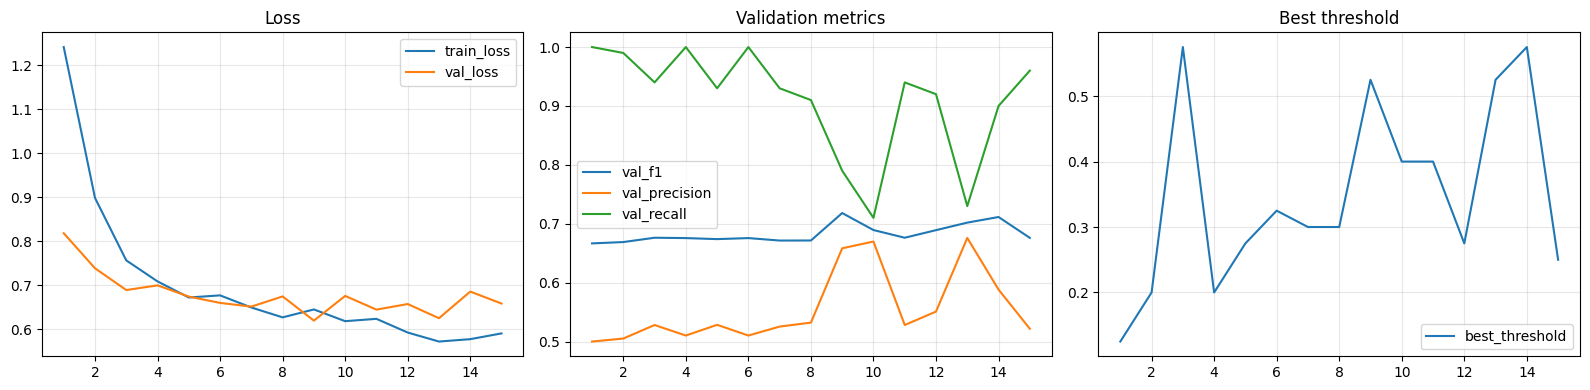

In [54]:
hist = mlp_result["history"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(hist["epoch"], hist["train_loss"], label="train_loss")
axes[0].plot(hist["epoch"], hist["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(hist["epoch"], hist["val_f1"], label="val_f1")
axes[1].plot(hist["epoch"], hist["val_precision"], label="val_precision")
axes[1].plot(hist["epoch"], hist["val_recall"], label="val_recall")
axes[1].set_title("Validation metrics")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(hist["epoch"], hist["best_threshold"], label="best_threshold")
axes[2].set_title("Best threshold")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()